# Neural Network - A Simple Perceptron


---

## Q1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

**Answer:**
* **Definition:** Deep Learning is a specialized subset of Machine Learning that uses multi-layered artificial neural networks to learn representations of data with multiple levels of abstraction.
* **Evolution:** It started with the **Perceptron** (1950s), evolved into **Multi-Layer Perceptrons** with backpropagation (1980s), and reached its current state in the 2010s thanks to the "Big Data" explosion and high-performance **GPUs**.
* **Differences from Traditional ML:**
    * **Feature Extraction:** Traditional ML requires manual feature engineering by experts. Deep Learning performs **automatic feature learning**.
    * **Performance:** Traditional ML models often plateau after a certain amount of data, whereas Deep Learning performance generally scales with more data.
    * **Complexity:** DL requires significantly more computational power and data to train effectively compared to traditional algorithms like Linear Regression or Decision Trees.

---

## Q2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

**Answer:**
* **Architecture:** A Perceptron consists of input values ($x_1, x_2, ... x_n$), corresponding weights ($w_1, w_2, ... w_n$), a bias ($b$), a summation function, and an activation function (typically a Step function).
* **Functioning:** 1. It calculates the weighted sum: $Z = (x_1w_1 + x_2w_2 + ... + x_nw_n) + b$.
    2. This sum $Z$ is passed through the activation function.
    3. If $Z \geq 0$, the output is 1; otherwise, the output is 0.
* **Limitations:** It is a linear classifier. It can only solve **linearly separable** problems. It famously fails to solve the **XOR gate** problem because the classes cannot be separated by a single straight line.

---

## Q3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

**Answer:**
* **Purpose:** Activation functions introduce **non-linearity**. Without them, a neural network—no matter how many layers it has—would behave like a simple linear model, unable to learn complex patterns in data.
* **Comparison:**
    * **Sigmoid:** Maps input to a range between **(0, 1)**. Often used in the output layer for binary classification. It can cause "vanishing gradients."
    * **Tanh (Hyperbolic Tangent):** Maps input to **(-1, 1)**. It is zero-centered, which usually makes it better for hidden layers than Sigmoid.
    * **ReLU (Rectified Linear Unit):** Maps negative inputs to 0 and positive inputs to $x$. It is the most popular hidden layer activation because it is computationally efficient and helps gradients flow better.

---

## Q4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

**Answer:**
* **Loss Function:** Refers to the error of a **single** training example. 
    * *Example:* **Binary Cross-Entropy** calculated for one specific transaction prediction.
* **Cost Function:** The **average** or sum of the loss functions over the entire training dataset. 
    * *Example:* **Mean Squared Error (MSE)** averaged across all samples in a training batch.

---

## Q5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

**Answer:**
* **Role:** Optimizers are algorithms that update the weights and learning rates of the network to minimize the cost function and improve accuracy.
* **Comparison:**
    * **Gradient Descent:** The baseline optimizer. Updates weights in the opposite direction of the gradient. It can be slow and get stuck in local minima.
    * **RMSprop:** Adjusts the learning rate for each weight by using a moving average of squared gradients, which helps in handling non-stationary objectives.
    * **Adam (Adaptive Moment Estimation):** Combines the benefits of RMSprop and Momentum. It is widely considered the "default" choice because it is fast, robust, and requires little tuning.

---

## Q6: Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.

In [3]:
import numpy as np

def step_function(x):
    return 1 if x >= 0 else 0

def perceptron_and_gate(inputs):
    # Manually defined weights and bias for AND logic
    weights = np.array([1, 1])
    bias = -1.5 
    
    linear_combination = np.dot(inputs, weights) + bias
    return step_function(linear_combination)

# Test inputs
test_data = [[0, 0], [0, 1], [1, 0], [1, 1]]

print("AND Gate Results:")
for data in test_data:
    print(f"Input: {data} | Output: {perceptron_and_gate(data)}")

AND Gate Results:
Input: [0, 0] | Output: 0
Input: [0, 1] | Output: 0
Input: [1, 0] | Output: 0
Input: [1, 1] | Output: 1


## Q7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.

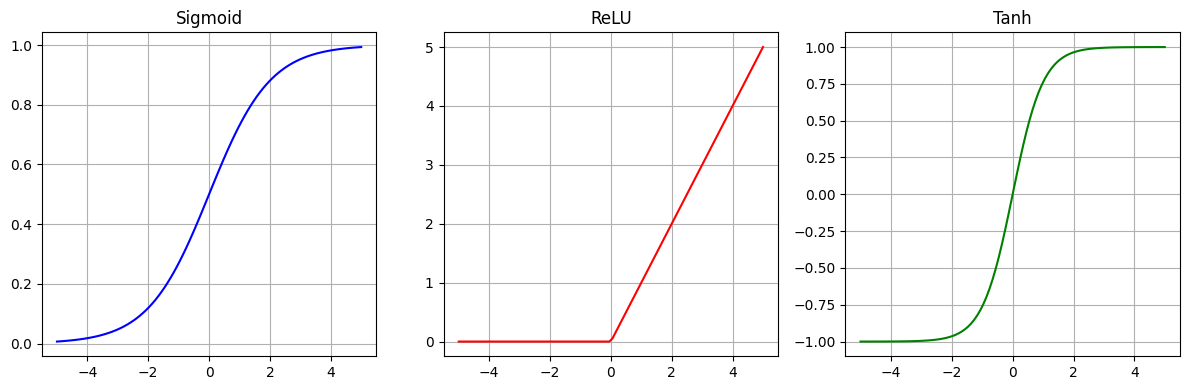

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(-5, 5, 100)
sig = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(x, sig, color='blue')
plt.title("Sigmoid")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(x, relu, color='red')
plt.title("ReLU")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(x, tanh, color='green')
plt.title("Tanh")
plt.grid(True)

plt.tight_layout()
plt.show()

## Q8: Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Load and normalize data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5, verbose=1)

# Accuracy output
final_acc = history.history['accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_acc * 100:.2f}%")

Epoch 1/5
   1/1875 [..............................] - ETA: 9:35 - loss: 2.3728 - accuracy: 0.1562

2026-03-24 19:58:19.013746: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1875/1875 [==============================] - 8s 4ms/step - loss: 0.3631 - accuracy: 0.8957
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3141 - accuracy: 0.9140
Epoch 3/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3199 - accuracy: 0.9124
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3291 - accuracy: 0.9105
Epoch 5/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.3413 - accuracy: 0.9100

Final Training Accuracy: 91.00%


## Q9: Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.

Epoch 1/5
   8/1875 [..............................] - ETA: 14s - loss: 202.1186 - accuracy: 0.2891 

2026-03-24 20:01:00.869694: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1874/1875 [============================>.] - ETA: 0s - loss: 27.0056 - accuracy: 0.7385

2026-03-24 20:01:10.860800: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1875/1875 [==============================] - 11s 6ms/step - loss: 27.0240 - accuracy: 0.7385 - val_loss: 26.4374 - val_accuracy: 0.7401
Epoch 2/5
1875/1875 [==============================] - 10s 5ms/step - loss: 26.3301 - accuracy: 0.7651 - val_loss: 25.3251 - val_accuracy: 0.7902
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 30.5672 - accuracy: 0.7726 - val_loss: 31.7751 - val_accuracy: 0.7756
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 33.8646 - accuracy: 0.7791 - val_loss: 40.8219 - val_accuracy: 0.7738
Epoch 5/5
1875/1875 [==============================] - 9s 5ms/step - loss: 35.4585 - accuracy: 0.7845 - val_loss: 34.6132 - val_accuracy: 0.7774


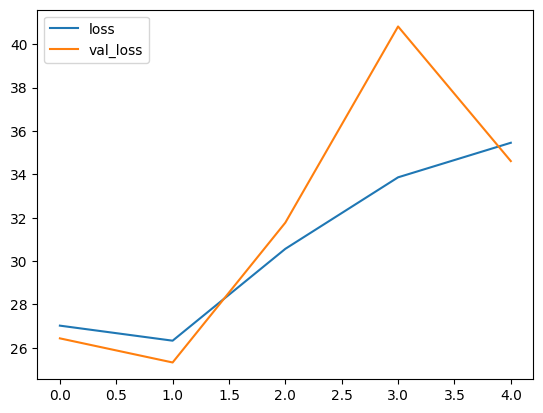

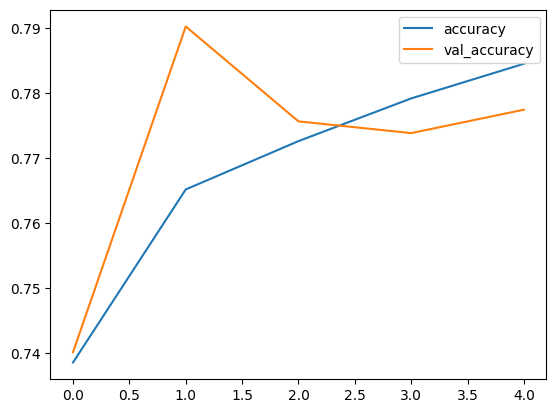

In [9]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test))

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.legend()
plt.show()

## Q10: Fraud Detection Workflow

You are working on a project for a bank that wants to automatically detect
fraudulent transactions. The dataset is large, imbalanced, and contains structured
features like transaction amount, merchant ID, and customer location. The goal is to
classify each transaction as fraudulent or legitimate.

**Explain your real-time data science workflow:**
1. How would you design a deep learning model (perceptron or multilayer NN)?
2. Which activation function and loss function would you use, and why?
3. How would you train and evaluate the model, considering class imbalance?
4. Which optimizer would be suitable, and how would you prevent overfitting?

**Answer:**

1. Design: I would design a Multilayer Neural Network. Fraud detection requires finding complex relationships between features like location and amount, which a single perceptron cannot handle.

2. Functions: ReLU for hidden layers to prevent vanishing gradients, and Sigmoid for the output layer to get a probability between 0 and 1. Binary Cross-Entropy is the required loss function for this binary task.

3. Imbalance: Since fraud is rare, I would use Class Weights during training or SMOTE to oversample the minority class. I would evaluate using Precision-Recall curves rather than accuracy.

4. Optimizer & Overfitting: I would use the Adam optimizer for efficiency. To prevent overfitting, I would use Dropout layers and Early Stopping based on validation loss.

In [10]:
# Conceptual implementation for Fraud Detection
model_fraud = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(30,)), # Assuming 30 features
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_fraud.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
print("Fraud Detection Model Architecture Ready.")

Fraud Detection Model Architecture Ready.
